In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/transactions_processed.csv")

df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Hour,Day,Month,Weekend,Amount Difference,Currency Match,Same Bank,Time Difference,Large Transaction
0,2022-09-01 00:00:00,1422,8014C7B60,1110,8017559F0,689.98,US Dollar,689.98,US Dollar,Cash,0,0,Thursday,9,False,0.0,True,False,NaN,False
1,2022-09-01 00:00:00,10416,806DC4EC0,10416,806DC4EC0,3.85,US Dollar,3.85,US Dollar,Reinvestment,0,0,Thursday,9,False,0.0,True,True,0.0,False
2,2022-09-01 00:00:00,2368,806DB8570,2368,806DB8570,4847.38,US Dollar,4847.38,US Dollar,Reinvestment,0,0,Thursday,9,False,0.0,True,True,0.0,False
3,2022-09-01 00:00:00,394,800B02E20,394,800B02E20,12.11,US Dollar,12.11,US Dollar,Reinvestment,0,0,Thursday,9,False,0.0,True,True,0.0,False
4,2022-09-01 00:00:00,21566,806DB5D90,21566,806DB5D90,3.55,US Dollar,3.55,US Dollar,Reinvestment,0,0,Thursday,9,False,0.0,True,True,0.0,False


In [3]:
graph_df = df.head(5000)


In [4]:
G = nx.DiGraph()

for _, row in graph_df.iterrows():
    G.add_edge(
        row["Account"],
        row["Account.1"],
        amount=row["Amount Paid"],
        timestamp=row["Timestamp"],
        is_laundering=row["Is Laundering"]
    )

print("Total nodes:", G.number_of_nodes())
print("Total edges:", G.number_of_edges())

Total nodes: 6023
Total edges: 4933


In [5]:
degree_centrality = nx.degree_centrality(G)

top_accounts = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

top_accounts

[('10042B660', 0.012786449684490202),
 ('80374FE50', 0.0006642311524410495),
 ('808622930', 0.0006642311524410495),
 ('80D231BF0', 0.0004981733643307871),
 ('80D1A5B00', 0.0004981733643307871),
 ('806C3B030', 0.0004981733643307871),
 ('802B32FC0', 0.0004981733643307871),
 ('8048AEB80', 0.0004981733643307871),
 ('80CED3B70', 0.0004981733643307871),
 ('8004D79F0', 0.0004981733643307871)]

In [6]:
degree_centrality = nx.degree_centrality(G)

top_accounts = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

top_accounts

[('10042B660', 0.012786449684490202),
 ('80374FE50', 0.0006642311524410495),
 ('808622930', 0.0006642311524410495),
 ('80D231BF0', 0.0004981733643307871),
 ('80D1A5B00', 0.0004981733643307871),
 ('806C3B030', 0.0004981733643307871),
 ('802B32FC0', 0.0004981733643307871),
 ('8048AEB80', 0.0004981733643307871),
 ('80CED3B70', 0.0004981733643307871),
 ('8004D79F0', 0.0004981733643307871)]

In [7]:
centrality_df = pd.DataFrame(
    top_accounts,
    columns=["Account", "Degree Centrality"]
)

centrality_df

,Account,Degree Centrality
0,10042B660,0.012786
1,80374FE50,0.000664
2,808622930,0.000664
3,80D231BF0,0.000498
4,80D1A5B00,0.000498
5,806C3B030,0.000498
6,802B32FC0,0.000498
7,8048AEB80,0.000498
8,80CED3B70,0.000498
9,8004D79F0,0.000498


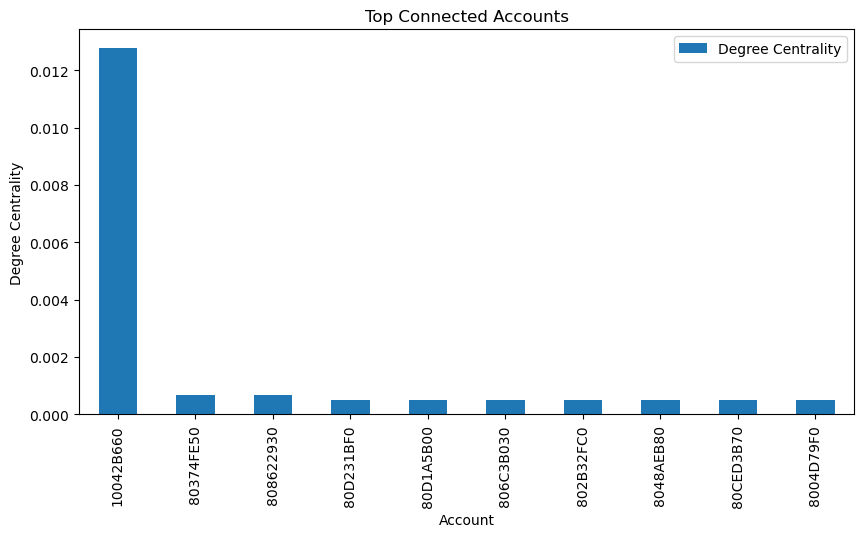

In [8]:
centrality_df.plot(
    x="Account",
    y="Degree Centrality",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Connected Accounts")
plt.xlabel("Account")
plt.ylabel("Degree Centrality")
plt.show()

In [9]:
cycles = list(nx.simple_cycles(G))

print("Circular transaction patterns found:", len(cycles))

cycles[:5]

Circular transaction patterns found: 3672


[['806DC4EC0'], ['806DB8570'], ['800B02E20'], ['806DB5D90'], ['80D2CD1E0']]

In [10]:
source = graph_df["Account"].iloc[0]
target = graph_df["Account.1"].iloc[-1]

try:
    path = nx.shortest_path(G, source=source, target=target)
    print("Money flow path:", path)
except:
    print("No path found")

No path found


In [11]:
graph_metrics = []

for account in G.nodes():
    graph_metrics.append({
        "Account": account,
        "Degree": G.degree(account),
        "In_Degree": G.in_degree(account),
        "Out_Degree": G.out_degree(account),
        "Degree_Centrality": degree_centrality.get(account, 0)
    })

graph_metrics_df = pd.DataFrame(graph_metrics)

graph_metrics_df.head()

,Account,Degree,In_Degree,Out_Degree,Degree_Centrality
0,8014C7B60,1,0,1,0.000166
1,8017559F0,1,1,0,0.000166
2,806DC4EC0,2,1,1,0.000332
3,806DB8570,2,1,1,0.000332
4,800B02E20,2,1,1,0.000332


In [12]:
graph_metrics_df.to_csv(
    "../data/processed/graph_metrics.csv",
    index=False
)